In [26]:
import pandas as pd
df_raw = pd.read_csv("dataset.csv")
df = df_raw.copy()

In [27]:
df.info()
df.columns.to_list()
print(df.head())
pd.set_option('display.max_columns', 100)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 88 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   collection_time_utc         583 non-null    object 
 1   source_weather              583 non-null    object 
 2   source_air                  583 non-null    object 
 3   source_city_selection       583 non-null    object 
 4   units_weather               583 non-null    object 
 5   country_code                583 non-null    object 
 6   country_name                583 non-null    object 
 7   country_capital             583 non-null    object 
 8   country_population          583 non-null    int64  
 9   continent                   509 non-null    object 
 10  city_name                   583 non-null    object 
 11  city_name_ascii             583 non-null    object 
 12  city_population             583 non-null    int64  
 13  population_rank_in_country  583 non

drop useless or redundant columns

In [28]:
df = df.drop(columns= [ # Metadata / useless
    "collection_time_utc", "source_weather", "source_air", "source_city_selection", "units_weather",

    # Country redundancy
    "country_name", "country_capital", "country_population", "continent",

    # Duplicate city info
    "city_name_ascii", "city_name_api", "city_id_openweather",

    # Geonames junk
    "geonames_feature_code", "geonameid", "geonames_modification_date",
    "city_timezone_geonames", "city_dem",

    # Weather redundant
    "weather_id", "weather_icon",

    # Raw timestamps
    "weather_time_unix", "weather_time_utc",
    "sunrise_unix", "sunrise_utc",
    "sunset_unix", "sunset_utc",
    "air_time_unix", "air_time_utc",
    "weather_datetime_utc", "air_datetime_utc",

    # Weak / redundant
    "station_country", "station_type", "cod", "wind_compass",

    # ⚠️ TARGET LEAKAGE (VERY IMPORTANT)
    "aqi", "aqi_label", "pm2_5", "pm10", "pm25_category"], errors= 'ignore')

In [29]:
df.head()

,country_code,city_name,city_population,population_rank_in_country,geo_lat,geo_lon,weather_main,weather_description,temp,feels_like,temp_min,temp_max,pressure,humidity,sea_level,grnd_level,visibility,wind_speed,wind_deg,wind_gust,clouds_all,rain_1h,rain_3h,snow_1h,snow_3h,timezone_shift_seconds,is_daytime,temp_category,comfort_proxy,has_rain,has_snow,co,no,no2,o3,so2,nh3,year,month,day,hour,day_of_week,is_weekend,season,temp_humidity_interaction,wind_pm25_interaction,pressure_temp_interaction,target_aqi_class,target_pm25,target_pm10
0,AD,Andorra la Vella,20430,1,42.50779,1.52109,Clouds,broken clouds,14.11,13.53,13.14,14.11,1020,75,1020,816,4676,0.45,242,1.34,69,0.0,0.0,0.0,0.0,7200,1,mild,21.61,0,0,135.40,0.17,6.88,66.71,0.33,16.07,2026,4,24,7,4,0,spring,1058.25,2.1195,14392.20,2,4.71,10.81
1,AD,les Escaldes,15853,2,42.50729,1.53414,Clouds,broken clouds,14.33,13.78,13.36,14.33,1020,75,1020,816,4676,0.45,242,1.34,69,0.0,0.0,0.0,0.0,7200,1,mild,21.83,0,0,135.40,0.17,6.88,66.71,0.33,16.07,2026,4,24,7,4,0,spring,1074.75,2.1195,14616.60,2,4.71,10.81
2,AE,Dubai,3790000,1,25.07725,55.30927,Clear,clear sky,35.84,34.65,35.84,36.05,1009,24,1009,1006,10000,3.09,15,3.27,8,0.0,0.0,0.0,0.0,14400,1,hot,38.24,0,0,187.29,5.33,14.91,90.17,7.62,0.40,2026,4,24,7,4,0,spring,860.16,87.7869,36162.56,4,28.41,116.85
3,AE,Abu Dhabi,1807000,2,24.45118,54.39696,Clear,clear sky,33.02,33.40,33.02,36.07,1010,38,1010,1010,10000,3.60,20,NaN,0,0.0,0.0,0.0,0.0,14400,1,hot,36.82,0,0,113.88,0.13,0.73,109.45,1.00,0.06,2026,4,24,7,4,0,spring,1254.76,65.0520,33350.20,3,18.07,97.68
4,AE,Sharjah,1800000,3,25.33420,55.41221,Clear,clear sky,36.00,34.86,36.00,36.18,1010,24,1010,1007,10000,3.60,360,NaN,0,0.0,0.0,0.0,0.0,14400,1,hot,38.40,0,0,182.82,4.50,14.42,93.22,6.91,0.52,2026,4,24,7,4,0,spring,864.00,113.2200,36360.00,4,31.45,122.41


encode the texts

In [30]:
cols = df.columns.to_list()
for col in cols:
  print(df[col].nunique())


209
580
579
3
582
583
9
15
525
525
519
521
30
91
30
162
20
243
207
238
67
32
1
1
1
26
2
5
506
2
1
519
126
295
516
256
286
1
1
1
2
1
1
1
578
535
570
5
419
475


In [31]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Threshold for unique values to decide between Label Encoding and One-Hot Encoding
unique_threshold = 10

# Prepare lists for columns to be Label Encoded and One-Hot Encoded
label_encode_cols = []
one_hot_encode_cols = []

for col in categorical_cols:
    if df[col].nunique() > unique_threshold:
        label_encode_cols.append(col)
    else:
        one_hot_encode_cols.append(col)

print(f"Columns for Label Encoding ({len(label_encode_cols)}): {label_encode_cols}")
print(f"Columns for One-Hot Encoding ({len(one_hot_encode_cols)}): {one_hot_encode_cols}")

Columns for Label Encoding (3): ['country_code', 'city_name', 'weather_description']
Columns for One-Hot Encoding (3): ['weather_main', 'temp_category', 'season']


In [32]:
# Apply Label Encoding
for col in label_encode_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Label encoded column: {col}")

Label encoded column: country_code
Label encoded column: city_name
Label encoded column: weather_description


In [33]:
# Apply One-Hot Encoding
if one_hot_encode_cols:
    df = pd.get_dummies(df, columns=one_hot_encode_cols, drop_first=True)
    print(f"One-Hot encoded columns: {one_hot_encode_cols}")
else:
    print("No columns for One-Hot Encoding based on the threshold.")

One-Hot encoded columns: ['weather_main', 'temp_category', 'season']


In [34]:
# Display the first few rows of the processed DataFrame
display(df.head())

,country_code,city_name,city_population,population_rank_in_country,geo_lat,geo_lon,weather_description,temp,feels_like,temp_min,temp_max,pressure,humidity,sea_level,grnd_level,visibility,wind_speed,wind_deg,wind_gust,clouds_all,rain_1h,rain_3h,snow_1h,snow_3h,timezone_shift_seconds,is_daytime,comfort_proxy,has_rain,has_snow,co,no,no2,o3,so2,nh3,year,month,day,hour,day_of_week,is_weekend,temp_humidity_interaction,wind_pm25_interaction,pressure_temp_interaction,target_aqi_class,target_pm25,target_pm10,weather_main_Clouds,weather_main_Drizzle,weather_main_Dust,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Thunderstorm,temp_category_freezing,temp_category_hot,temp_category_mild,temp_category_warm
0,0,20,20430,1,42.50779,1.52109,0,14.11,13.53,13.14,14.11,1020,75,1020,816,4676,0.45,242,1.34,69,0.0,0.0,0.0,0.0,7200,1,21.61,0,0,135.40,0.17,6.88,66.71,0.33,16.07,2026,4,24,7,4,0,1058.25,2.1195,14392.20,2,4.71,10.81,True,False,False,False,False,False,False,False,False,False,True,False
1,0,576,15853,2,42.50729,1.53414,0,14.33,13.78,13.36,14.33,1020,75,1020,816,4676,0.45,242,1.34,69,0.0,0.0,0.0,0.0,7200,1,21.83,0,0,135.40,0.17,6.88,66.71,0.33,16.07,2026,4,24,7,4,0,1074.75,2.1195,14616.60,2,4.71,10.81,True,False,False,False,False,False,False,False,False,False,True,False
2,1,149,3790000,1,25.07725,55.30927,1,35.84,34.65,35.84,36.05,1009,24,1009,1006,10000,3.09,15,3.27,8,0.0,0.0,0.0,0.0,14400,1,38.24,0,0,187.29,5.33,14.91,90.17,7.62,0.40,2026,4,24,7,4,0,860.16,87.7869,36162.56,4,28.41,116.85,False,False,False,False,False,False,False,False,False,True,False,False
3,1,3,1807000,2,24.45118,54.39696,1,33.02,33.40,33.02,36.07,1010,38,1010,1010,10000,3.60,20,NaN,0,0.0,0.0,0.0,0.0,14400,1,36.82,0,0,113.88,0.13,0.73,109.45,1.00,0.06,2026,4,24,7,4,0,1254.76,65.0520,33350.20,3,18.07,97.68,False,False,False,False,False,False,False,False,False,True,False,False
4,1,488,1800000,3,25.33420,55.41221,1,36.00,34.86,36.00,36.18,1010,24,1010,1007,10000,3.60,360,NaN,0,0.0,0.0,0.0,0.0,14400,1,38.40,0,0,182.82,4.50,14.42,93.22,6.91,0.52,2026,4,24,7,4,0,864.00,113.2200,36360.00,4,31.45,122.41,False,False,False,False,False,False,False,False,False,True,False,False


In [35]:
# Display information about the DataFrame to see new dtypes and column count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 59 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country_code                583 non-null    int64  
 1   city_name                   583 non-null    int64  
 2   city_population             583 non-null    int64  
 3   population_rank_in_country  583 non-null    int64  
 4   geo_lat                     583 non-null    float64
 5   geo_lon                     583 non-null    float64
 6   weather_description         583 non-null    int64  
 7   temp                        583 non-null    float64
 8   feels_like                  583 non-null    float64
 9   temp_min                    583 non-null    float64
 10  temp_max                    583 non-null    float64
 11  pressure                    583 non-null    int64  
 12  humidity                    583 non-null    int64  
 13  sea_level                   583 non

noticed that wind gust has quite a few missing values. might be because of the sensors didnt work or maybe the wind was 0 so we put wind gus = 0 for NAN

In [36]:
df['wind_gust'] = df['wind_gust'].fillna(0)

In [42]:
df.duplicated().sum()

np.int64(0)

the dataset is actually ready for ML and we choose AQI as the target and will predict that

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [51]:
from sklearn.model_selection import train_test_split
import xgboost as xgb


X = df.drop('target_aqi_class', axis=1)
y = df['target_aqi_class'] - 1

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Classifier
model = xgb.XGBClassifier()
model.fit(X_train, y_train)
model.predict(X_test)

print("XGBoost Classifier trained successfully!")

XGBoost Classifier trained successfully!


Accuracy: 0.9829

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       0.98      1.00      0.99        40
           2       1.00      0.96      0.98        24
           3       0.89      1.00      0.94         8
           4       1.00      0.50      0.67         2

    accuracy                           0.98       117
   macro avg       0.97      0.89      0.91       117
weighted avg       0.98      0.98      0.98       117



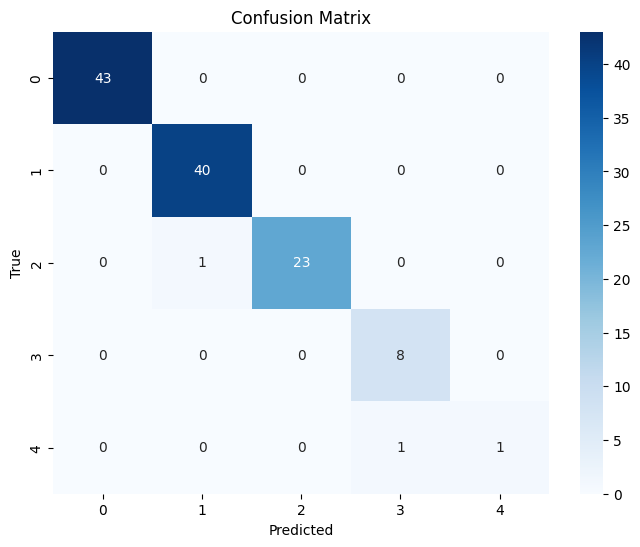

In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

the accuracy is too perfect and the dataset is imbalanced. we check if the importances of the columns

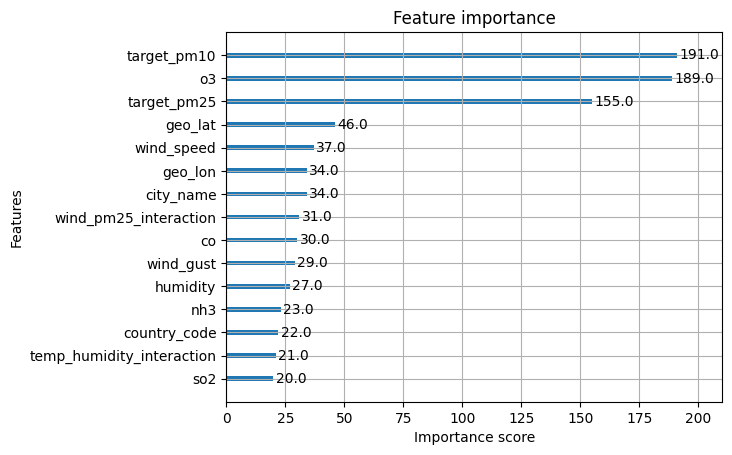

In [53]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, max_num_features=15)
plt.show()

lmaoo, we remove the factors based on what AQI is predicted

In [54]:
leakage_cols = [
    "target_pm25",
    "target_pm10",
    "pm2_5",
    "pm10",
    "aqi",
    "aqi_label",
    "pm25_category",
    "co", "no", "no2", "o3", "so2", "nh3",
    "wind_pm25_interaction"
]

df = df.drop(columns=leakage_cols, errors="ignore")

### Retraining the model after removing leakage features

Now that the leakage columns have been dropped, we will re-split the data and retrain the XGBoost model to evaluate its performance with the refined feature set.

In [57]:
# Redefine features (X) and target (y) with the updated DataFrame
X = df.drop('target_aqi_class', axis=1)
y = df['target_aqi_class'] - 1 # Ensure y is 0-indexed

# Re-split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-initialize and train the XGBoost Classifier
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

print("XGBoost Classifier re-trained successfully with reduced features!")

XGBoost Classifier re-trained successfully with reduced features!


Accuracy: 0.6923

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.95      0.86        43
           1       0.65      0.75      0.70        40
           2       0.54      0.29      0.38        24
           3       0.60      0.38      0.46         8
           4       0.00      0.00      0.00         2

    accuracy                           0.69       117
   macro avg       0.52      0.47      0.48       117
weighted avg       0.66      0.69      0.66       117



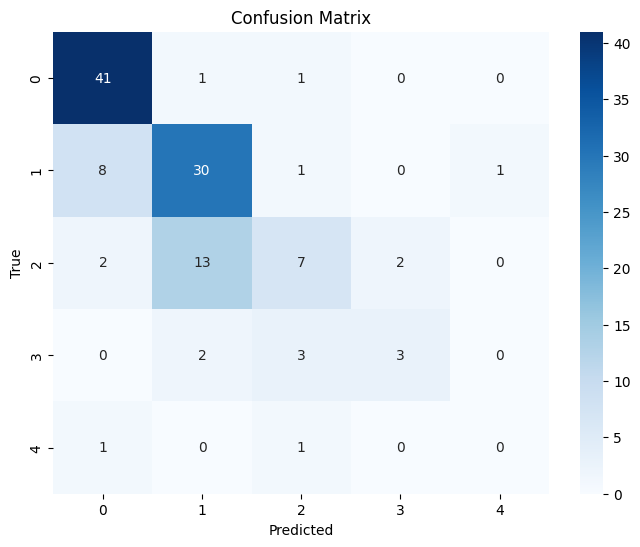

In [58]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

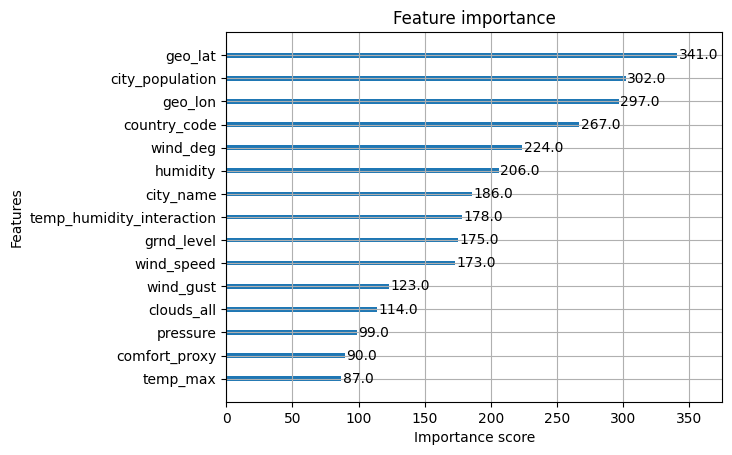

In [59]:
xgb.plot_importance(model, max_num_features=15)
plt.show()

now this seems realistic
might improve the model tmr or drop it cuz its only current time data. would have made a model to do weather forecasting otherwise